In [7]:
import numpy as np
import matplotlib.pyplot as plt
import gc

# 1. Feedforward Neural Network

In [8]:
train_x = np.load('fashion/train_x.npy').reshape(-1, 784)
train_y = np.load('fashion/train_y.npy')
test_x = np.load('fashion/test_x.npy').reshape(-1, 784)
test_y = np.load('fashion/test_y.npy')

# normalize
train_x = train_x / 255.0
test_x = test_x / 255.0

print(train_x.shape)
# print(train_x[0])
print(train_y.shape)
print(train_y[0:5])
print(test_x.shape)
print(test_y.shape)

(60000, 784)
(60000,)
[9 0 0 3 0]
(10000, 784)
(10000,)


In [9]:
weights = np.load('weights.npy', allow_pickle=True)
print(weights.item().keys())
weight_1 = weights.item()['w1']
bias_1 = weights.item()['b1']
weight_2 = weights.item()['w2']
bias_2 = weights.item()['b2']
weight_3 = weights.item()['w3']
bias_3 = weights.item()['b3']
print("weight 1 shape:",weight_1.shape)
print("bias 1 shape:",bias_1.shape)
print("weight 2 shape:",weight_2.shape)
print("bias 2 shape:",bias_2.shape)
print("weight 3 shape:",weight_3.shape)
print("bias 3 shape:",bias_3.shape)
weights_dict = {'w1': weight_1, 'b1': bias_1, 'w2': weight_2, 'b2': bias_2, 'w3': weight_3, 'b3': bias_3}

dict_keys(['w1', 'b1', 'w2', 'b2', 'w3', 'b3'])
weight 1 shape: (784, 2048)
bias 1 shape: (2048, 1)
weight 2 shape: (2048, 512)
bias 2 shape: (512, 1)
weight 3 shape: (512, 10)
bias 3 shape: (10, 1)


In [10]:
weight_1_zeros = np.zeros(weight_1.shape)
bias_1_zeros = np.zeros(bias_1.shape)
weight_2_zeros = np.zeros(weight_2.shape)
bias_2_zeros = np.zeros(bias_2.shape)
weight_3_zeros = np.zeros(weight_3.shape)
bias_3_zeros = np.zeros(bias_3.shape)
print("weight 1 zeros shape:",weight_1_zeros.shape)
print("bias 1 zeros shape:",bias_1_zeros.shape)
print("weight 2 zeros shape:",weight_2_zeros.shape)
print("bias 2 zeros shape:",bias_2_zeros.shape)
print("weight 3 zeros shape:",weight_3_zeros.shape)
print("bias 3 zeros shape:",bias_3_zeros.shape)
weights_zeros_dict = {'w1': weight_1_zeros, 'b1': bias_1_zeros, 'w2': weight_2_zeros, 'b2': bias_2_zeros, 'w3': weight_3_zeros, 'b3': bias_3_zeros}

weight 1 zeros shape: (784, 2048)
bias 1 zeros shape: (2048, 1)
weight 2 zeros shape: (2048, 512)
bias 2 zeros shape: (512, 1)
weight 3 zeros shape: (512, 10)
bias 3 zeros shape: (10, 1)


In [11]:
class FNN():
    def __init__(self, train_x, train_y, test_x, test_y, weights, dropout_rate = 0.0, shuffle=False):
        self.train_x = train_x
        self.train_y = train_y
        self.test_x = test_x
        self.test_y = test_y
        self.weight_1 = weights['w1'].copy()
        self.weight_2 = weights['w2'].copy()
        self.weight_3 = weights['w3'].copy()
        self.bias_1 =  weights['b1'].copy()
        self.bias_2 =  weights['b2'].copy()
        self.bias_3 =  weights['b3'].copy()
        self.dropout_rate = dropout_rate
        self.shuffle = shuffle
        self.classes = 10
        self.epochs = 30
        self.lr = 0.01
        self.batch_size = 200
        self.train_acc = []
        self.test_acc = []
        self.train_loss = []
        self.test_loss = []
        
    
    def relu(self, x, derivative=False):
        if derivative:
            return np.where(x > 0, 1, 0)
        return np.maximum(0, x)
    
    #stable softmax can test softmax
    def softmax(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)
    
    def cross_entropy(self, y, y_hat):
       y_onehot = np.eye(self.classes)[y]
       y_hat = np.clip(y_hat, 1e-7, 1-1e-7)
       return -np.sum(y_onehot * np.log(y_hat)) / y.shape[0]
    
    def softmax_cross_entropy_backprop(self, y, y_hat):
        y_onehot = np.eye(self.classes)[y]
        return (y_hat - y_onehot)
    
    def forward(self, x, dropout_rate = 0.0):
        #(batch_size, 784) @ (784, 2048) + (2048,1) = (batch_size, 2048)
        self.z1 = (x @ self.weight_1) + self.bias_1.T
        self.a1 = self.relu(self.z1)
        #dropout mask, block layer output
        mask1 = np.random.binomial(1, 1-dropout_rate, self.a1.shape)
        self.a1 *= mask1 / (1-dropout_rate)
        #(batch_size, 2048) @ (2048, 512) + (512,1) = (batch_size, 512)
        self.z2 = (self.a1 @ self.weight_2) + self.bias_2.T
        self.a2 = self.relu(self.z2)
        #dropout mask, block layer output
        mask2 = np.random.binomial(1, 1-dropout_rate, self.a2.shape)
        self.a2 *= mask2 / (1-dropout_rate)
        #(batch_size, 512) @ (512, 10) + (10,1) = (batch_size, 10)
        self.z3 = (self.a2 @ self.weight_3) + self.bias_3.T
        self.a3 = self.softmax(self.z3)
        return self.a3
    
    def backward(self, x, y_hat, y):
        #(batch_size, 10) derivative of softmax
        self.d_a3 = self.softmax_cross_entropy_backprop(y, y_hat)
        #(batch_size, 512) = (batch_size, 10) @ (10, 512)
        self.d_z3 = self.d_a3 @ self.weight_3.T
        #(batch_size, 512) * derivative of relu
        self.d_a2 = self.d_z3 * self.relu(self.a2, derivative=True)
        #(batch_size, 2048) = (batch_size, 512) @ (512, 2048)
        self.d_z2 = self.d_a2 @ self.weight_2.T
        
        self.d_a1 = self.d_z2 * self.relu(self.a1, derivative=True)
        
        #update parameters by mini-batch SGD
        #(512, 10) = (512, batch_size) @ (batch_size, 10) divide by batch_size
        self.weight_3 -= self.lr * ((self.a2.T @ self.d_a3) / self.batch_size)
        #(1, 10) = (batch_size, 10) divide by batch_size
        self.bias_3 -= self.lr * np.mean(self.d_a3, axis=0).reshape(-1,1)
        #(2048, 512) = (2048, batch_size) @ (batch_size, 512) divide by batch_size
        self.weight_2 -= self.lr * ((self.a1.T @ self.d_a2) / self.batch_size)
        #(1, 512) = (batch_size, 512) divide by batch_size
        self.bias_2 -= self.lr * np.mean(self.d_a2, axis=0).reshape(-1,1)
        #(784, 2048) = (784, batch_size) @ (batch_size, 2048) divide by batch_size
        self.weight_1 -= self.lr * ((x.T @ self.d_a1) / self.batch_size)
        #(1, 2048) = (batch_size, 2048) divide by batch_size
        self.bias_1 -= self.lr * np.mean(self.d_a1, axis=0).reshape(-1,1)
        
    def fit(self):
        self.train_acc = []
        self.test_acc = []
        self.train_loss = []
        self.test_loss = []
        #60000 / 200 = 300
        mini_batch_num = int(np.ceil(self.train_x.shape[0] / self.batch_size))
        for epoch in range(self.epochs):
            for i in range(mini_batch_num):
                start = i * self.batch_size
                end = (i+1) * self.batch_size
                x = self.train_x[start:end]
                y = self.train_y[start:end]
                if self.shuffle:
                    np.random.seed(42)
                    np.random.shuffle(x)
                    np.random.seed(42)
                    np.random.shuffle(y)
                y_hat = self.forward(x, self.dropout_rate)
                self.backward(x, y_hat, y)
                if (i+1) % 25 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs}, batch {i+1}/{mini_batch_num}")
                    all_train_y_hat = self.forward(self.train_x, self.dropout_rate)
                    train_acc = np.sum(np.argmax(all_train_y_hat, axis=1) == self.train_y)/self.train_x.shape[0]
                    train_loss = self.cross_entropy(self.train_y, all_train_y_hat)
                    print(f"train acc: {train_acc}, train loss: {train_loss}")
                    test_y_hat = self.forward(self.test_x)
                    test_acc = np.sum(np.argmax(test_y_hat, axis=1) == self.test_y)/self.test_x.shape[0]
                    test_loss = self.cross_entropy(self.test_y, test_y_hat)
                    print(f"test acc: {test_acc}, test loss: {test_loss}")
                    print("=====================================")
                    self.train_acc.append(train_acc)
                    self.test_acc.append(test_acc)
                    self.train_loss.append(train_loss)
                    self.test_loss.append(test_loss)
    def plot_train_fig(self):
        plt.subplot(1,2,1)
        plt.plot(np.arange(len(self.train_loss)), self.train_loss, label='train loss')
        plt.plot(np.arange(len(self.test_loss)), self.test_loss, label='test loss')
        plt.title('Train Loss Curve')
        plt.legend()
        
        plt.subplot(1,2,2)
        plt.plot(np.arange(len(self.train_acc)), self.train_acc, label='train acc')
        plt.plot(np.arange(len(self.test_acc)), self.test_acc, label='test acc')
        plt.title('Train Accuracy Curve')
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f"Final train acc: {self.train_acc[-1]}, test acc: {self.test_acc[-1]}")
        print(f"Final train loss: {self.train_loss[-1]}, test loss: {self.test_loss[-1]}")

# 1.(a) Plot the learning curves of J(w) and the accuracy of classification for every 25 iterations, with training data as well as test data, also, show the final loss and accuracy values.

In [12]:
model = FNN(train_x, train_y, test_x, test_y, weights_dict)
model.fit()

Epoch 1/30, batch 25/300
train acc: 0.696, train loss: 4.529249639973581
test acc: 0.6863, test loss: 4.692143253950106
Epoch 1/30, batch 50/300
train acc: 0.6865833333333333, train loss: 4.129431259609641
test acc: 0.6765, test loss: 4.266568607487245
Epoch 1/30, batch 75/300
train acc: 0.6865666666666667, train loss: 3.509822354222996
test acc: 0.6729, test loss: 3.677125991618651
Epoch 1/30, batch 100/300
train acc: 0.6618, train loss: 3.1849846602057745
test acc: 0.6453, test loss: 3.3556859606925165
Epoch 1/30, batch 125/300
train acc: 0.65545, train loss: 2.8712378772645057
test acc: 0.6393, test loss: 3.077653006398739
Epoch 1/30, batch 150/300
train acc: 0.6471666666666667, train loss: 2.6684267383010254
test acc: 0.6349, test loss: 2.8258040345856044
Epoch 1/30, batch 175/300
train acc: 0.6568833333333334, train loss: 2.496446813708942
test acc: 0.646, test loss: 2.6410769489047183
Epoch 1/30, batch 200/300
train acc: 0.6384666666666666, train loss: 2.3850181590792925
test acc

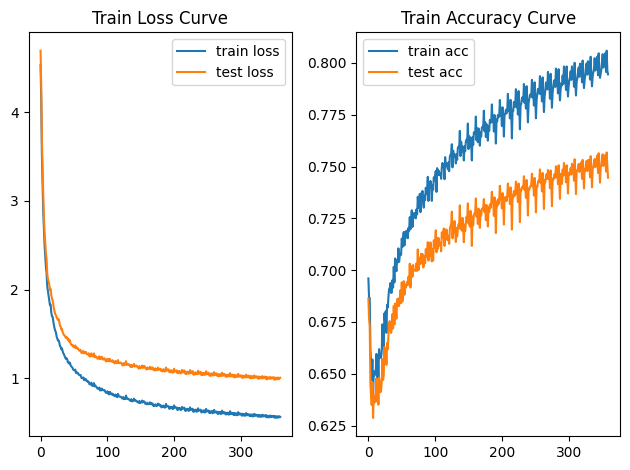

Final train acc: 0.7944666666666667, test acc: 0.7446
Final train loss: 0.5663377313670814, test loss: 1.0058439216781605


In [13]:
model.plot_train_fig()

In [14]:
#delete trained model release memory
del model
gc.collect()

6805

# 1.(b) Repeat 1(a) by considering zero initialization for the model weights. And make some discussion.
    因為網路中的參數都初始化為0
    所以網路的output也都為0
    並且在做倒傳遞時也因為這個原因導致算出的梯度也為0
    因此無法更新參數優化loss網路也無法訓練

In [15]:
model_zeros = FNN(train_x, train_y, test_x, test_y, weights_zeros_dict)
model_zeros.fit()

Epoch 1/30, batch 25/300
train acc: 0.1, train loss: 2.302585771121786
test acc: 0.1, test loss: 2.3025857711217848
Epoch 1/30, batch 50/300
train acc: 0.1, train loss: 2.3025858643979342
test acc: 0.1, test loss: 2.3025858643979342
Epoch 1/30, batch 75/300
train acc: 0.1, train loss: 2.3025861203545994
test acc: 0.1, test loss: 2.3025861203546
Epoch 1/30, batch 100/300
train acc: 0.1, train loss: 2.3025865251785302
test acc: 0.1, test loss: 2.3025865251785307
Epoch 1/30, batch 125/300
train acc: 0.1, train loss: 2.302586630053602
test acc: 0.1, test loss: 2.3025866300536024
Epoch 1/30, batch 150/300
train acc: 0.1, train loss: 2.3025866797109464
test acc: 0.1, test loss: 2.302586679710946
Epoch 1/30, batch 175/300
train acc: 0.1, train loss: 2.3025863151745485
test acc: 0.1, test loss: 2.3025863151745485
Epoch 1/30, batch 200/300
train acc: 0.1, train loss: 2.3025864905739777
test acc: 0.1, test loss: 2.302586490573978
Epoch 1/30, batch 225/300
train acc: 0.1, train loss: 2.3025858055

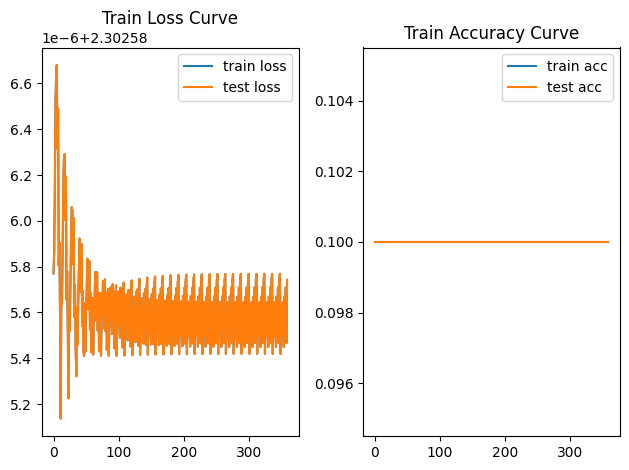

Final train acc: 0.1, test acc: 0.1
Final train loss: 2.3025857422683282, test loss: 2.3025857422683274


In [16]:
model_zeros.plot_train_fig()

In [17]:
#delete trained model release memory
del model_zeros
gc.collect()

6919

# 2. (a) Implement the dropout technique in the feedforward neural network and repeat 1(a).

In [18]:
model_dropout = FNN(train_x, train_y, test_x, test_y, weights_dict, dropout_rate=0.2)
model_dropout.fit()

Epoch 1/30, batch 25/300
train acc: 0.615, train loss: 6.067199064209438
test acc: 0.6814, test loss: 4.933847480422965
Epoch 1/30, batch 50/300
train acc: 0.6278333333333334, train loss: 5.797384978214354
test acc: 0.7022, test loss: 4.366347466633291
Epoch 1/30, batch 75/300
train acc: 0.6391666666666667, train loss: 5.542593117476987
test acc: 0.6957, test loss: 4.119859221147194
Epoch 1/30, batch 100/300
train acc: 0.63615, train loss: 5.500701157255869
test acc: 0.6902, test loss: 3.5118453912508114
Epoch 1/30, batch 125/300
train acc: 0.6371166666666667, train loss: 5.390948863763711
test acc: 0.701, test loss: 3.1347935681380807
Epoch 1/30, batch 150/300
train acc: 0.632, train loss: 5.273714491350855
test acc: 0.6895, test loss: 2.639466417606336
Epoch 1/30, batch 175/300
train acc: 0.6293666666666666, train loss: 5.223974851309848
test acc: 0.6513, test loss: 3.4415129334441366
Epoch 1/30, batch 200/300
train acc: 0.6272833333333333, train loss: 5.035369552052068
test acc: 0.6

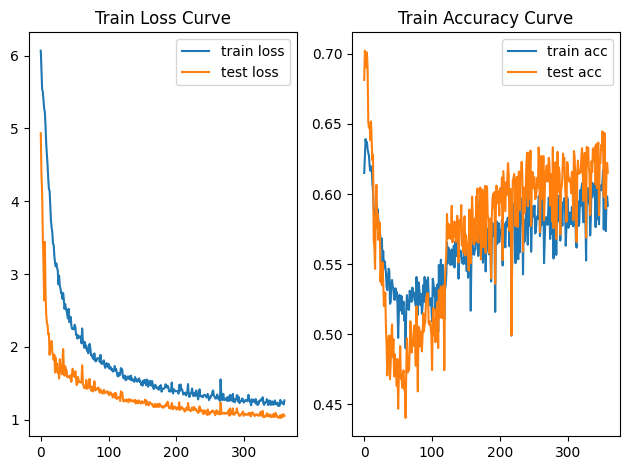

Final train acc: 0.5916666666666667, test acc: 0.6152
Final train loss: 1.2649327881925971, test loss: 1.0541111959618654


In [19]:
model_dropout.plot_train_fig()

In [20]:
#delete trained model release memory
del model_dropout
gc.collect()

6861

# 2.(b) Based on the experimental results, how do the dropout layers affect the model performance and why? Please make some discussion.
    Dropout可以讓網路在訓練時隨機的關閉一些神經元藉此來防止網路overfitting
    會導致train的準確率下降loss上升而test的準確率上升loss下降
    不過可能是因為網路在加dropout前
    本來就有一些underfitting的問題
    所以效果不太顯著甚至導致test準確率變得更差

# 3. (a) Implement mini-batch SGD, and plot the learning curves of J(w) and the classification accuracy for every 25 iterations. Please show the final values of loss and accuracy 

In [21]:
model_mini_batch = FNN(train_x, train_y, test_x, test_y, weights_dict, shuffle=True)
model_mini_batch.fit()

Epoch 1/30, batch 25/300
train acc: 0.696, train loss: 4.529249639970015
test acc: 0.6863, test loss: 4.692143253943175
Epoch 1/30, batch 50/300
train acc: 0.6865833333333333, train loss: 4.129431259573371
test acc: 0.6765, test loss: 4.266568607412967
Epoch 1/30, batch 75/300
train acc: 0.6865666666666667, train loss: 3.5098223541444358
test acc: 0.6729, test loss: 3.6771259915303314
Epoch 1/30, batch 100/300
train acc: 0.6618, train loss: 3.184984659721131
test acc: 0.6453, test loss: 3.355685960390627
Epoch 1/30, batch 125/300
train acc: 0.65545, train loss: 2.8712378773060445
test acc: 0.6393, test loss: 3.0776530050807898
Epoch 1/30, batch 150/300
train acc: 0.6471666666666667, train loss: 2.668426738681903
test acc: 0.6349, test loss: 2.825804034197283
Epoch 1/30, batch 175/300
train acc: 0.6568833333333334, train loss: 2.4964468105701454
test acc: 0.646, test loss: 2.641076945826106
Epoch 1/30, batch 200/300
train acc: 0.6384666666666666, train loss: 2.3850181646123483
test acc:

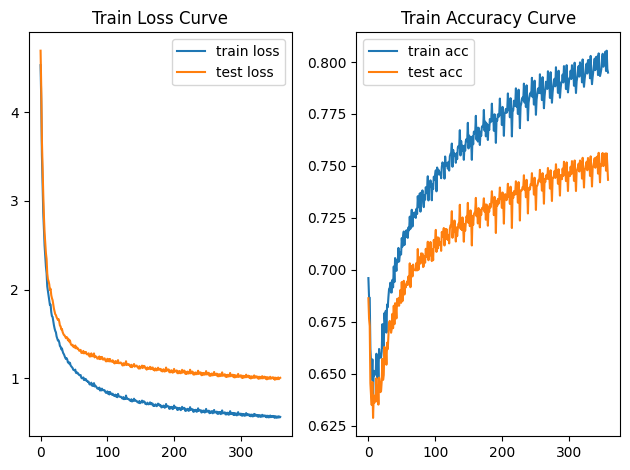

Final train acc: 0.7949166666666667, test acc: 0.7433
Final train loss: 0.5657014507810557, test loss: 1.006484257730703


In [22]:
model_mini_batch.plot_train_fig()

In [23]:
#delete trained model release memory
del model_mini_batch
gc.collect()

6856

# 3.(b) Based on the experimental results, how the process of reshuffling images affect the model performance and why? Please make some discussion.
shuffle可以讓網路在訓練時不會只學習到固定的順序
用來防止網路overfitting及學習到一些不屬於資料的特徵
但是因為網路本身有些underfitting
所以效果不太顯著

# 1. Convolutional Neural Network

# 1. Please implement a CNN for image recognition by using 10 Monkey Species, then plot the learning curve and the accuracy rate of training and test data.

In [18]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [19]:

CNN_epochs = 30
CNN_batchsize = 128
CNN_lr = 0.001

transforms_setup = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.CenterCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),# 0-255 to 0-1
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.ImageFolder(root='./monkey/train/', transform=transforms_setup)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=CNN_batchsize, shuffle=True, num_workers=2)

test_set = torchvision.datasets.ImageFolder(root='./monkey/test/', transform=transforms_setup)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=CNN_batchsize, shuffle=True, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

In [20]:
print(train_set[0][0].shape)
print(train_set[0][1], train_set[500][1])

torch.Size([3, 256, 256])
0 4


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


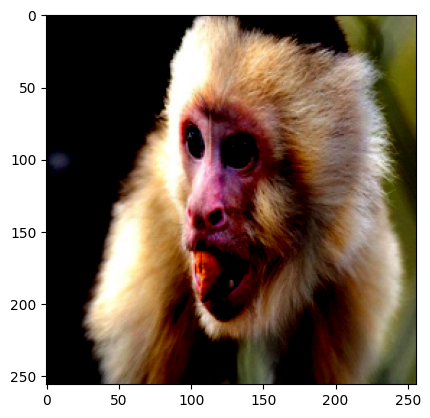

In [21]:
plt.imshow(train_set[650][0].permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([128, 3, 256, 256]) torch.Size([128])


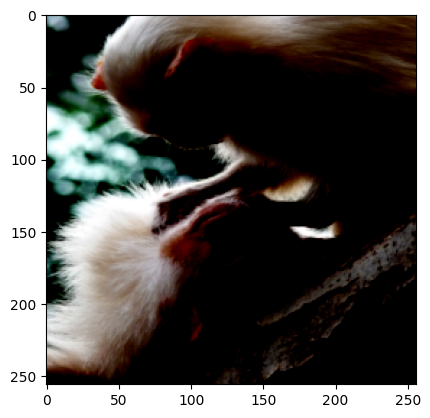

In [22]:
for i, data in enumerate(train_loader):
    features, labels = data
    print(features.shape, labels.shape)
    plt.imshow(features[0].permute(1, 2, 0))
    break

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            # input 3x256x256
            nn.Conv2d(3, 32, kernel_size=3,padding=2),# 32x258x258
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 32x129x129
        )
        self.conv2 = nn.Sequential(
            # input 32x129x129
            nn.Conv2d(32, 64, kernel_size=3, padding=2),# 64x131x131
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 64x65x65
        )
        self.conv3 = nn.Sequential(
            # input 64x65x65
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 128x65x65
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 128x32x32
        )
        self.conv4 = nn.Sequential(
            # input 128x32x32
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 256x32x32 
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 256x16x16
        )
        self.conv5 = nn.Sequential(
            # input 256x16x16
            nn.Conv2d(256, 512, kernel_size=3, padding=1),# 512x16x16 
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 512x8x8
        )
        self.fc = nn.Sequential(
            # input 512x8x8 flatten
            nn.Linear(512*8*8, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10),
            nn.Softmax(dim=1)
        )
        self.dropout = nn.Dropout(0.4)
    def forward(self, x):
        x = self.conv1(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.dropout(x)
        x = self.conv3(x)
        x = self.dropout(x)
        x = self.conv4(x)
        x = self.dropout(x)
        x = self.conv5(x)
        x = self.dropout(x)
        x = x.view( x.size(0), -1)
        x = self.fc(x)
        return x
    

In [24]:
model_cnn = CNN().to(device)
print(model_cnn)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=CNN_lr)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(

In [25]:
training_loss_history = []
testing_loss_history = []
training_accuracy_history = []
testing_accuracy_history = []
for epoch in range(CNN_epochs):
    training_loss = 0.0
    training_correct = 0
    model_cnn.train()
    for data in train_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(inputs)
        training_predicted = outputs.max(1, keepdim=True)[1]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        training_correct += training_predicted.eq(labels.view_as(training_predicted)).sum().item()
    training_loss_history.append(training_loss/len(train_loader))
    training_accuracy_history.append(training_correct/len(train_set))
    
    with torch.no_grad():
        testing_loss = 0.0
        testing_correct = 0
        model_cnn.eval()
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            testing_predicted = outputs.max(1, keepdim=True)[1]
            loss = criterion(outputs, labels)
            testing_loss += loss.item()
            testing_correct += testing_predicted.eq(labels.view_as(testing_predicted)).sum().item()
        testing_loss_history.append(testing_loss/len(test_loader))
        testing_accuracy_history.append(testing_correct/len(test_set))
    print(f"Epoch {epoch+1}/{CNN_epochs}, Training Loss: {training_loss_history[-1]}, Training Accuracy: {training_accuracy_history[-1]}, Testing Loss: {testing_loss_history[-1]}, Testing Accuracy: {testing_accuracy_history[-1]}")
    

Epoch 1/30, Training Loss: 2.2230993111928306, Training Accuracy: 0.2880583409298086, Testing Loss: 2.3021183013916016, Testing Accuracy: 0.15441176470588236
Epoch 2/30, Training Loss: 2.1369868914286294, Training Accuracy: 0.4621695533272562, Testing Loss: 2.2591705322265625, Testing Accuracy: 0.1801470588235294
Epoch 3/30, Training Loss: 2.0898503727383084, Training Accuracy: 0.5132178669097539, Testing Loss: 2.266545136769613, Testing Accuracy: 0.20955882352941177
Epoch 4/30, Training Loss: 2.039335595236884, Training Accuracy: 0.5569735642661805, Testing Loss: 2.230142672856649, Testing Accuracy: 0.2647058823529412
Epoch 5/30, Training Loss: 2.008782002660963, Training Accuracy: 0.5587967183226983, Testing Loss: 2.205073436101278, Testing Accuracy: 0.2867647058823529
Epoch 6/30, Training Loss: 1.9681513839297824, Training Accuracy: 0.6034639927073838, Testing Loss: 2.1621834437052407, Testing Accuracy: 0.28308823529411764
Epoch 7/30, Training Loss: 1.9309090773264568, Training Accu

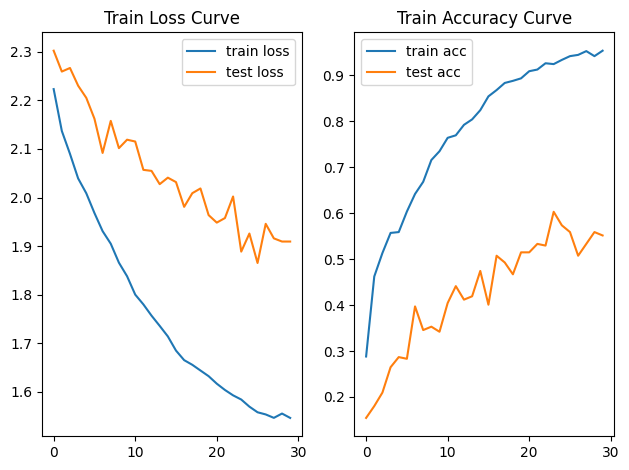

In [26]:
plt.subplot(1,2,1)
plt.plot(np.arange(len(training_loss_history)), training_loss_history, label='train loss')
plt.plot(np.arange(len(testing_loss_history)), testing_loss_history, label='test loss')
plt.title('Train Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(len(training_accuracy_history)), training_accuracy_history, label='train acc')
plt.plot(np.arange(len(testing_accuracy_history)), testing_accuracy_history, label='test acc')
plt.title('Train Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
#delete trained model release memory
del training_loss_history, testing_loss_history, training_accuracy_history, testing_accuracy_history
gc.collect()
del model_cnn
torch.cuda.empty_cache()

# 2. To deal with a real-world problem, we may stack some additional layers in the Deep Neural Network which results in improved accuracy and performance. However, it has been found that there is a maximum threshold for depth with the traditional convolutional neural network model. The problem of training a very deep network has been alleviated with the introduction of ResNet or residual network.

# 2.(a) Construct a ResNet with residual blocks for image recognition and plot the learning curve, accuracy rate, try to stack more blocks as you can (ResNet-18 is recommended), you can refer to the paper for implementation.

In [28]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, identity=True, downsample=False):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride[0], padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride[1], padding=1)
        self.downsample_layer = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride[0],padding=0),
            nn.BatchNorm2d(out_channels)
        )
        self.downsample = downsample
        self.identity = identity
       
    def forward(self, x):
        if self.identity:
            if self.downsample:
                identity_x = self.downsample_layer(x)
                out = self.downsample_layer(x)
            else:
                identity_x = x
                out = self.conv1(x)
            out = self.bn1(out)
            out = self.relu(out)
            out = self.conv2(out)
            out = self.bn1(out)
            out += identity_x
            out = self.relu(out)
        else:
            if self.downsample:
                out = self.downsample_layer(x)
            else:
                out = self.conv1(x)
            out = self.bn1(out)
            out = self.relu(out)
            out = self.conv2(out)
            out = self.bn1(out)
            out = self.relu(out)  
        return out
    
class ResNet18(nn.Module):
    def __init__(self, identity=True):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv2_x = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            ResidualBlock(64, 64, stride=(1,1), identity=identity),
            ResidualBlock(64, 64, stride=(1,1), identity=identity)
        )
        self.conv3_x = nn.Sequential(
            ResidualBlock(64, 128, stride=(2,1), identity=identity, downsample=True),
            ResidualBlock(128, 128, stride=(1,1), identity=identity)
        )
        self.conv4_x = nn.Sequential(
            ResidualBlock(128, 256, stride=(2,1), identity=identity, downsample=True),
            ResidualBlock(256, 256, stride=(1,1), identity=identity)
        )
        self.conv5_x = nn.Sequential(
            ResidualBlock(256, 512, stride=(2,1), identity=identity, downsample=True),
            ResidualBlock(512, 512, stride=(1,1), identity=identity)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(512, 10),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2_x(x)
        x = self.conv3_x(x)
        x = self.conv4_x(x)
        x = self.conv5_x(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [29]:
model_ResNet18 = ResNet18().to(device)
print(model_ResNet18)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model_ResNet18.parameters(), lr=CNN_lr)

ResNet18(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv2_x): Sequential(
    (0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (downsample_layer): Sequential(
        (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

In [30]:
training_loss_history = []
testing_loss_history = []
training_accuracy_history = []
testing_accuracy_history = []
for epoch in range(CNN_epochs):
    training_loss = 0.0
    training_correct = 0
    model_ResNet18.train()
    for data in train_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_ResNet18(inputs)
        training_predicted = outputs.max(1, keepdim=True)[1]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        training_correct += training_predicted.eq(labels.view_as(training_predicted)).sum().item()
    training_loss_history.append(training_loss/len(train_loader))
    training_accuracy_history.append(training_correct/len(train_set))
    
    with torch.no_grad():
        testing_loss = 0.0
        testing_correct = 0
        model_ResNet18.eval()
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model_ResNet18(images)
            testing_predicted = outputs.max(1, keepdim=True)[1]
            loss = criterion(outputs, labels)
            testing_loss += loss.item()
            testing_correct += testing_predicted.eq(labels.view_as(testing_predicted)).sum().item()
        testing_loss_history.append(testing_loss/len(test_loader))
        testing_accuracy_history.append(testing_correct/len(test_set))
    print(f"Epoch {epoch+1}/{CNN_epochs}, Training Loss: {training_loss_history[-1]}, Training Accuracy: {training_accuracy_history[-1]}, Testing Loss: {testing_loss_history[-1]}, Testing Accuracy: {testing_accuracy_history[-1]}")
    

Epoch 1/30, Training Loss: 2.195085260603163, Training Accuracy: 0.24339106654512307, Testing Loss: 2.222391446431478, Testing Accuracy: 0.21323529411764705
Epoch 2/30, Training Loss: 2.116941319571601, Training Accuracy: 0.3272561531449407, Testing Loss: 2.1802786191304526, Testing Accuracy: 0.28308823529411764
Epoch 3/30, Training Loss: 2.053799351056417, Training Accuracy: 0.41294439380127623, Testing Loss: 2.179647445678711, Testing Accuracy: 0.26838235294117646
Epoch 4/30, Training Loss: 2.043945484691196, Training Accuracy: 0.4211485870556062, Testing Loss: 2.259923775990804, Testing Accuracy: 0.22058823529411764
Epoch 5/30, Training Loss: 2.032991091410319, Training Accuracy: 0.4247948951686418, Testing Loss: 2.10337241490682, Testing Accuracy: 0.3161764705882353
Epoch 6/30, Training Loss: 1.9747084379196167, Training Accuracy: 0.49225159525979945, Testing Loss: 2.078645706176758, Testing Accuracy: 0.34191176470588236
Epoch 7/30, Training Loss: 1.946457200580173, Training Accura

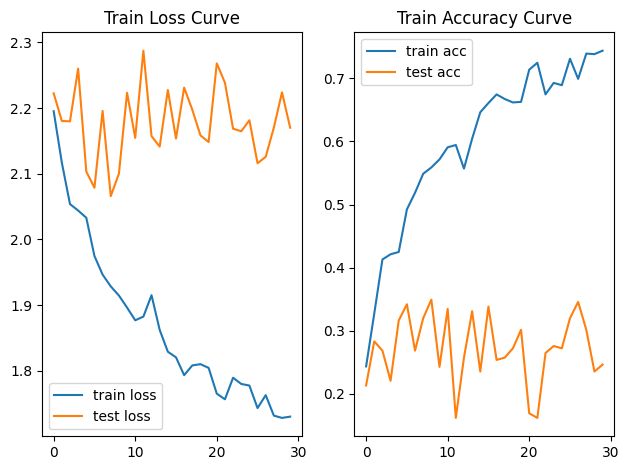

In [31]:
plt.subplot(1,2,1)
plt.plot(np.arange(len(training_loss_history)), training_loss_history, label='train loss')
plt.plot(np.arange(len(testing_loss_history)), testing_loss_history, label='test loss')
plt.title('Train Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(len(training_accuracy_history)), training_accuracy_history, label='train acc')
plt.plot(np.arange(len(testing_accuracy_history)), testing_accuracy_history, label='test acc')
plt.title('Train Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
#delete trained model release memory
del training_loss_history, testing_loss_history, training_accuracy_history, testing_accuracy_history
gc.collect()
del model_ResNet18  
torch.cuda.empty_cache()

# 2.(b) Remove the identity mapping and repeat (a), then make some discussion on the results of (a) and (b). Please describe what you found.
    在(a)跟(b)的learning curve可以看到準確率跟loss的變化都是有identify mapping的模型有比較好的結果
    因為在網路層數越多的情況下資料的傳遞也會越來越困難
    而identity mapping可以讓資料在網路中往前傳遞的時候不容易退化、消失
    讓我們可以使用更深的網路學習資料更多的特徵提升準確率

In [33]:
model_ResNet18_without_identity = ResNet18(identity=False).to(device)
print(model_ResNet18_without_identity)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model_ResNet18_without_identity.parameters(), lr=CNN_lr)

ResNet18(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv2_x): Sequential(
    (0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (downsample_layer): Sequential(
        (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

In [34]:
training_loss_history = []
testing_loss_history = []
training_accuracy_history = []
testing_accuracy_history = []
for epoch in range(CNN_epochs):
    training_loss = 0.0
    training_correct = 0
    model_ResNet18_without_identity.train()
    for data in train_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_ResNet18_without_identity(inputs)
        training_predicted = outputs.max(1, keepdim=True)[1]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        training_correct += training_predicted.eq(labels.view_as(training_predicted)).sum().item()
    training_loss_history.append(training_loss/len(train_loader))
    training_accuracy_history.append(training_correct/len(train_set))
    
    with torch.no_grad():
        testing_loss = 0.0
        testing_correct = 0
        model_ResNet18_without_identity.eval()
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model_ResNet18_without_identity(images)
            testing_predicted = outputs.max(1, keepdim=True)[1]
            loss = criterion(outputs, labels)
            testing_loss += loss.item()
            testing_correct += testing_predicted.eq(labels.view_as(testing_predicted)).sum().item()
        testing_loss_history.append(testing_loss/len(test_loader))
        testing_accuracy_history.append(testing_correct/len(test_set))
    print(f"Epoch {epoch+1}/{CNN_epochs}, Training Loss: {training_loss_history[-1]}, Training Accuracy: {training_accuracy_history[-1]}, Testing Loss: {testing_loss_history[-1]}, Testing Accuracy: {testing_accuracy_history[-1]}")
    

Epoch 1/30, Training Loss: 2.2363038857777915, Training Accuracy: 0.2096627164995442, Testing Loss: 2.301555792490641, Testing Accuracy: 0.15808823529411764
Epoch 2/30, Training Loss: 2.1445455021328397, Training Accuracy: 0.29808568824065634, Testing Loss: 2.2410046259562173, Testing Accuracy: 0.1801470588235294
Epoch 3/30, Training Loss: 2.104259490966797, Training Accuracy: 0.34913400182315407, Testing Loss: 2.319063742955526, Testing Accuracy: 0.09558823529411764
Epoch 4/30, Training Loss: 2.0879861778683133, Training Accuracy: 0.3646308113035551, Testing Loss: 2.2861135005950928, Testing Accuracy: 0.1213235294117647
Epoch 5/30, Training Loss: 2.092468367682563, Training Accuracy: 0.35733819507748404, Testing Loss: 2.249321460723877, Testing Accuracy: 0.16911764705882354
Epoch 6/30, Training Loss: 2.061746504571703, Training Accuracy: 0.390154968094804, Testing Loss: 2.297285000483195, Testing Accuracy: 0.1213235294117647
Epoch 7/30, Training Loss: 2.059820148679945, Training Accur

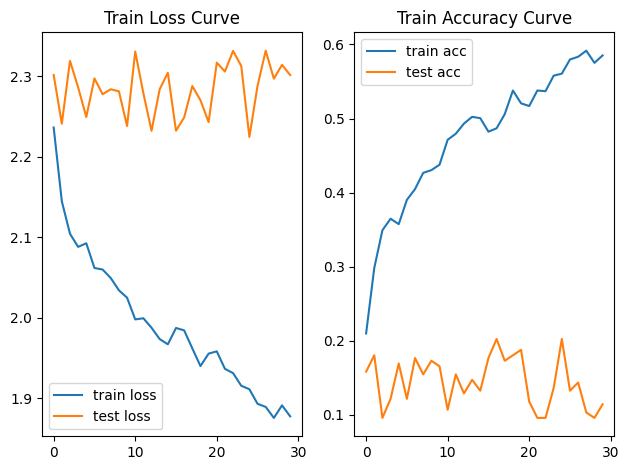

In [35]:
plt.subplot(1,2,1)
plt.plot(np.arange(len(training_loss_history)), training_loss_history, label='train loss')
plt.plot(np.arange(len(testing_loss_history)), testing_loss_history, label='test loss')
plt.title('Train Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(len(training_accuracy_history)), training_accuracy_history, label='train acc')
plt.plot(np.arange(len(testing_accuracy_history)), testing_accuracy_history, label='test acc')
plt.title('Train Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()